In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import bosperrus
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scanpy as sc

In [3]:
import sys
sys.path.append("../../src/utils/")
import visium_hd
from border_fit import ALL_SAMPLES, FIT_PALETTE, MIN_COMPONENT_SPOTS, get_grid_components, get_or_compute_component_fit, native_pixel_size_um

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [4]:
ALL_SAMPLES

,name,dataset_type,loader,h5ad_path,bin_size_um,tissue_mask_path
0,breast_cancer,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
1,pancreas,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
2,colon_cancer_ff,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
3,breast_cancer_tma,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
4,Pat1,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
5,Pat2,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
6,Pat3,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
7,Pat4,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
8,A02991D1,stomics_custom,stomics,/home/woody/iwbn/iwbn007h/spatial_data/stomics...,10.0,/home/woody/iwbn/iwbn007h/spatial_data/stomics...
9,A02994C6,stomics_custom,stomics,/home/woody/iwbn/iwbn007h/spatial_data/stomics...,10.0,/home/woody/iwbn/iwbn007h/spatial_data/stomics...


In [5]:
i = 3
h5ad_path = ALL_SAMPLES["h5ad_path"].iloc[i]
bin_size_um = ALL_SAMPLES["bin_size_um"].iloc[i]
library_id = ALL_SAMPLES["name"].iloc[i]

In [6]:
adata = sc.read_h5ad(h5ad_path)
adata.obs["n_counts"] = adata.X.sum(axis=1)

In [7]:
adata

AnnData object with n_obs × n_vars = 415161 × 18085
    obs: 'array_row', 'array_col', 'in_tissue', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
    layers: None (.X)

In [8]:
bosperrus.anndata_api.identify_analysis_buffer(adata, row_key="array_row", col_key="array_col", grid_type="rect", n_counts_key="n_counts", bin_size_um=bin_size_um, min_component_size=1000, distance_key="distance_to_border", score="n_counts")

In [9]:
adata

AnnData object with n_obs × n_vars = 415161 × 18085
    obs: 'array_row', 'array_col', 'in_tissue', 'n_counts', 'components', 'distance_to_border', 'border', 'analysis_buffer'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'analysis_buffer_fit'
    obsm: 'spatial'
    layers: None (.X)

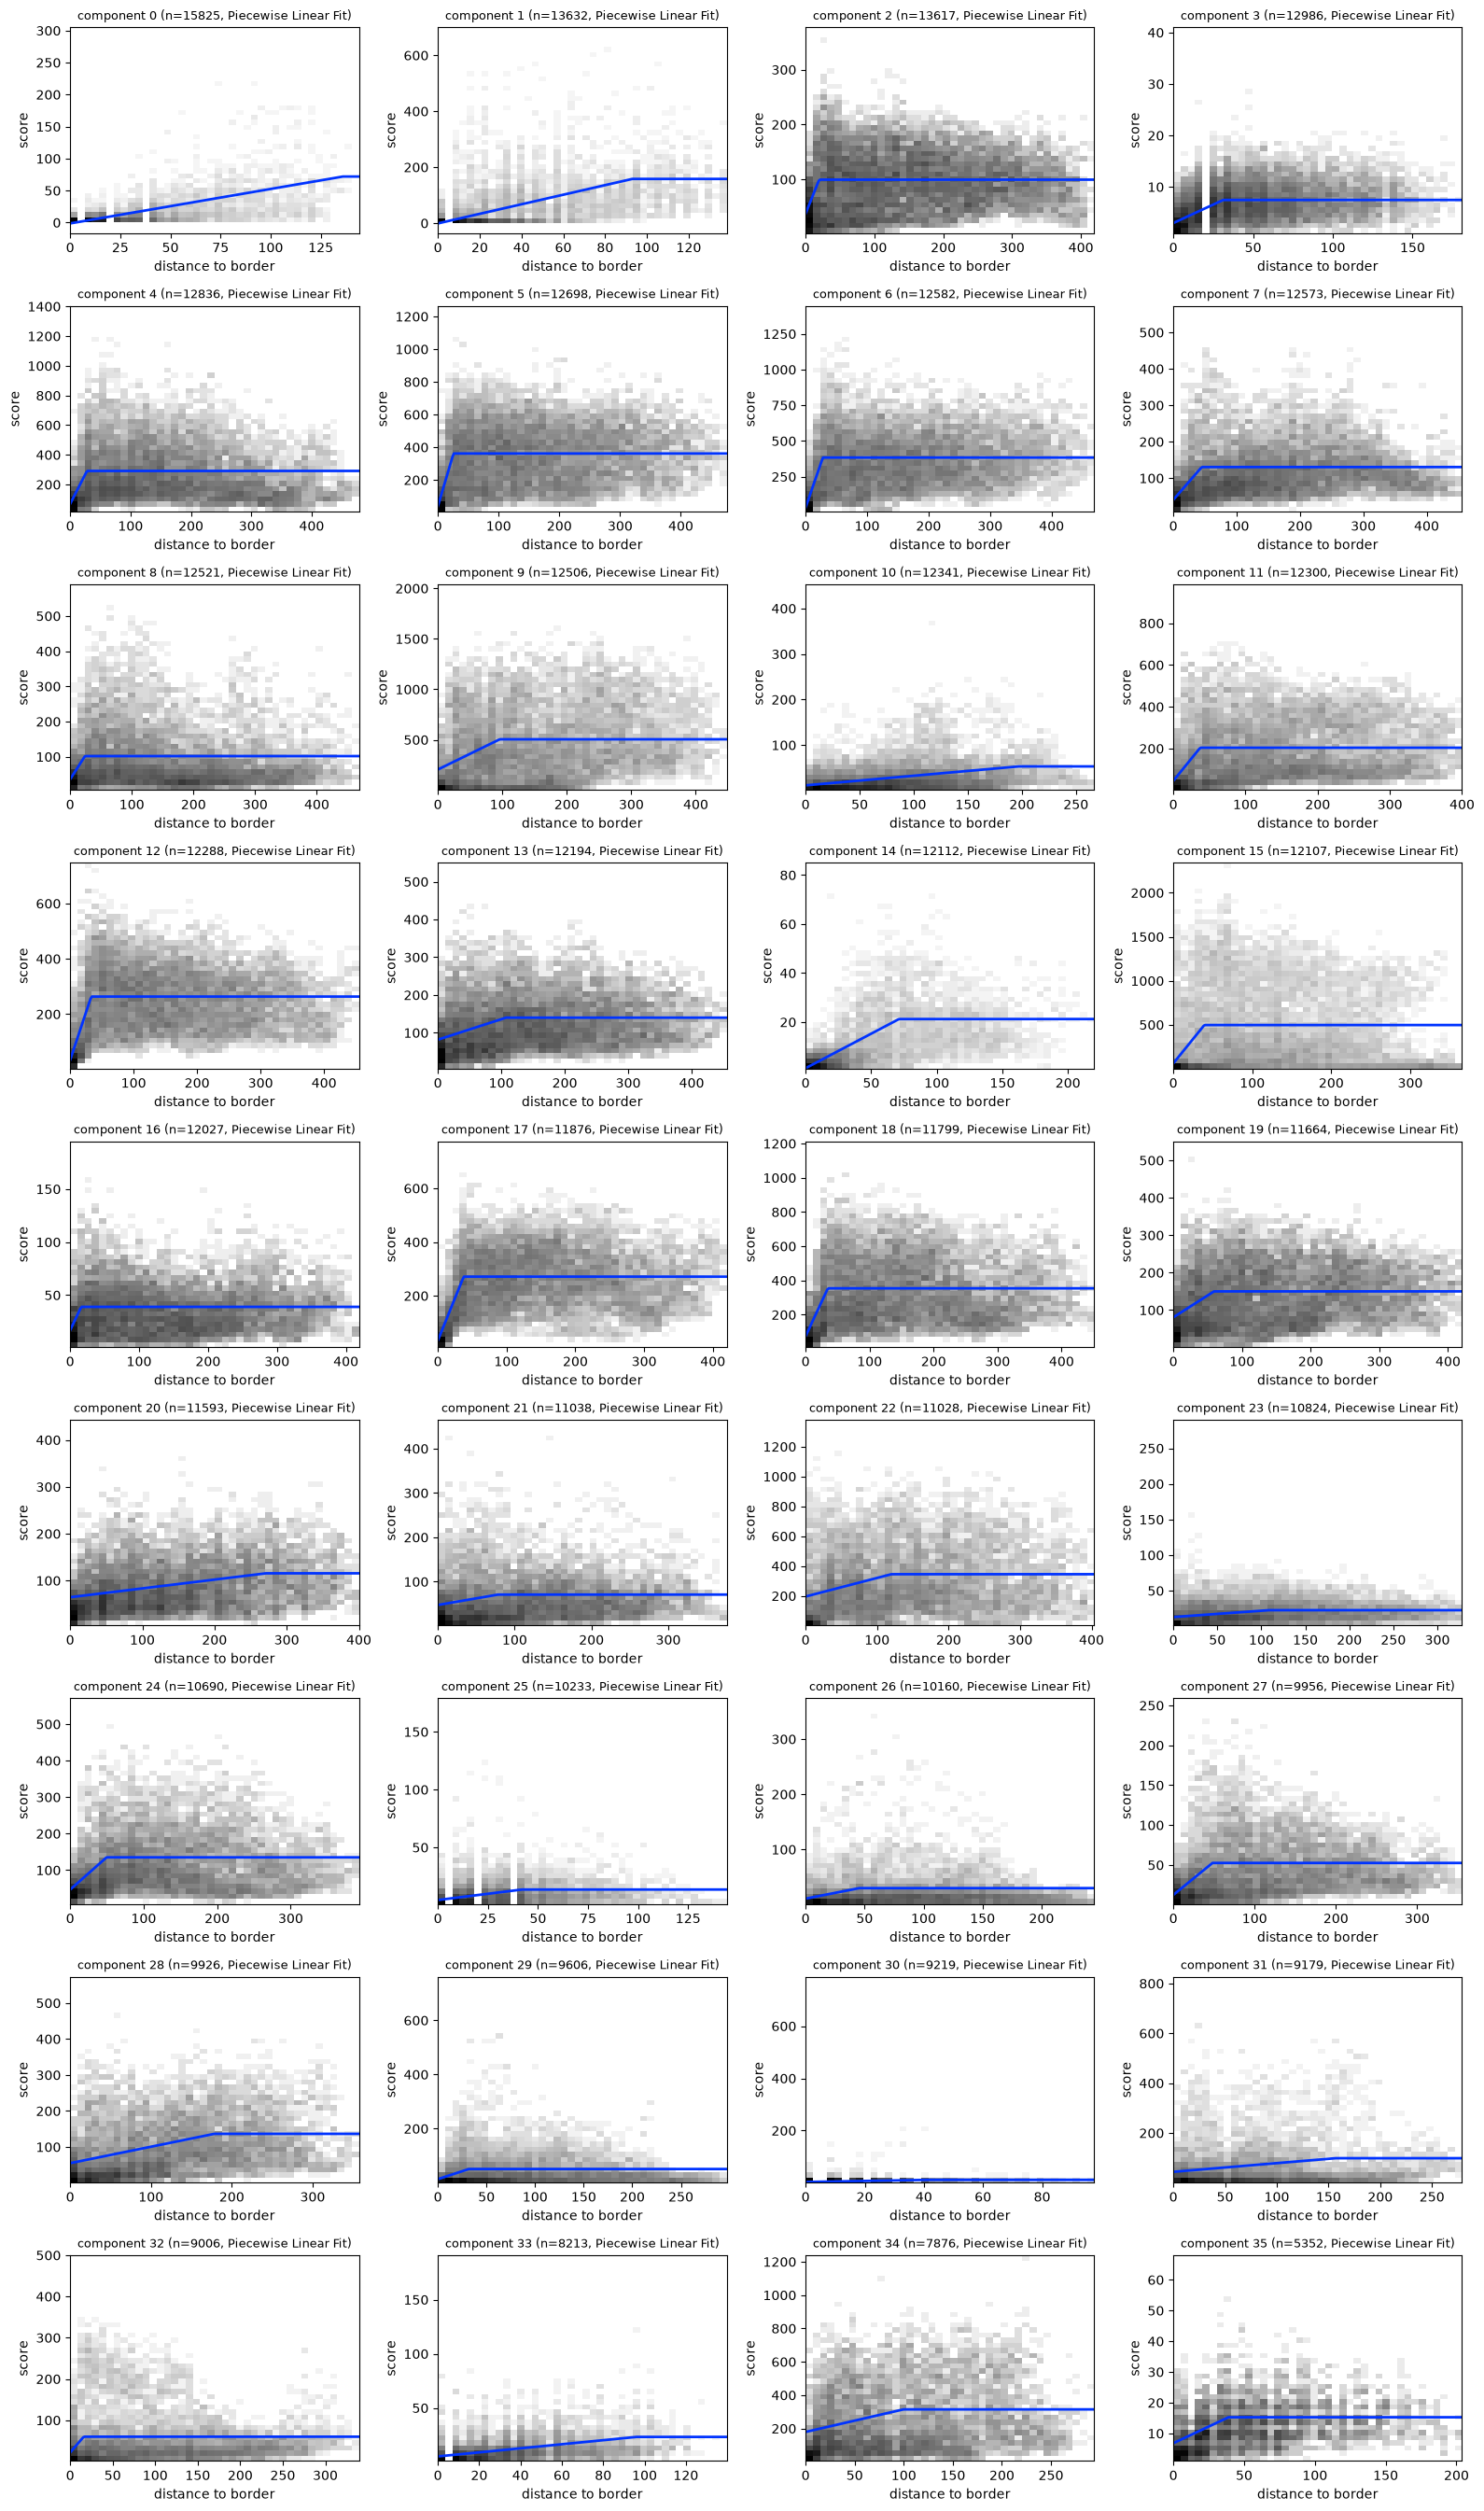

In [10]:
fig = bosperrus.anndata_api.plot_border_effect(adata, score="n_counts")
plt.show()

/tmp/1538279.tinyfat/ipykernel_1607548/1205035800.py:2: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="components")


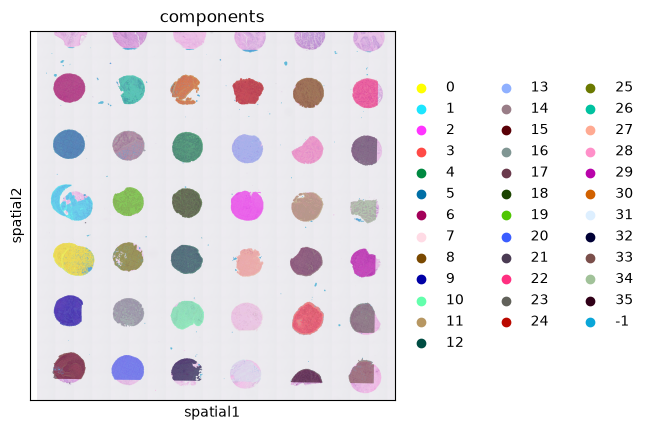

In [11]:
adata.obs["components"] = adata.obs["components"].astype(str)
sc.pl.spatial(adata, color="components")

/tmp/1538279.tinyfat/ipykernel_1607548/1308691713.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs["components"] == "1"], color=["n_counts", "border", "distance_to_border", "analysis_buffer"])
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/scanpy/plotting/_utils.py:511: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


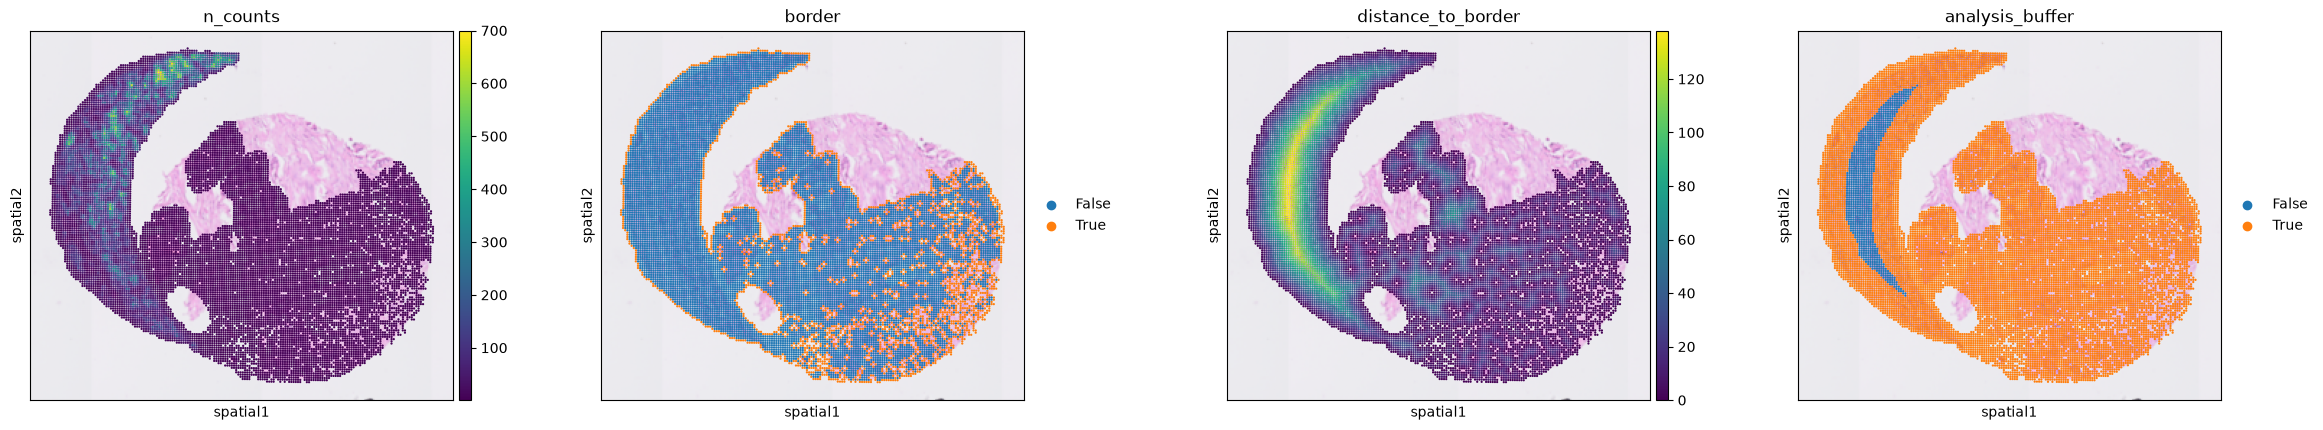

In [12]:
sc.pl.spatial(adata[adata.obs["components"] == "1"], color=["n_counts", "border", "distance_to_border", "analysis_buffer"])

/tmp/1538279.tinyfat/ipykernel_1607548/4232724260.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs["components"] == "5"], color=["n_counts", "border", "distance_to_border", "analysis_buffer"])
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/scanpy/plotting/_utils.py:511: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


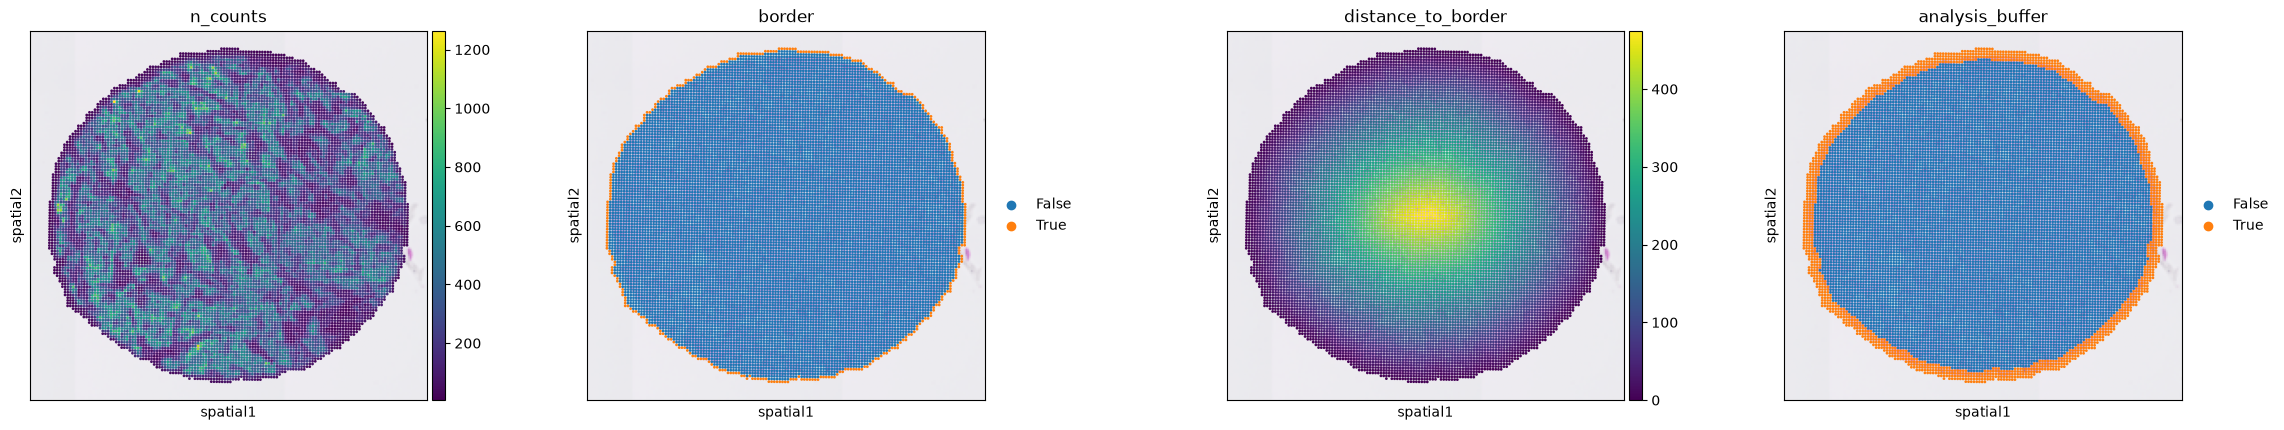

In [13]:
sc.pl.spatial(adata[adata.obs["components"] == "5"], color=["n_counts", "border", "distance_to_border", "analysis_buffer"])

In [14]:
bosperrus.quantify_diffusion(adata, library_id=library_id, score="n_counts", row_key="array_row", col_key="array_col", grid_type="rect", n_counts_key="n_counts", bin_size_um=1.0, min_component_size=0, components_key="components", image_key="hires", mask_distance_key="distance_to_image_mask", key_added="diffusion", segment_kwargs=None, copy=False)

/home/woody/iwbn/iwbn007h/bosperrus/bosperrus-package/bosperrus/image_masks.py:117: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(close_radius))
/home/woody/iwbn/iwbn007h/bosperrus/bosperrus-package/bosperrus/image_masks.py:118: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_holes(mask, area_threshold=min_hole_area)
/home/woody/iwbn/iwbn007h/bosperrus/bosperrus-package/bosperrus/image_masks.py:119: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0

In [15]:
adata

AnnData object with n_obs × n_vars = 415161 × 18085
    obs: 'array_row', 'array_col', 'in_tissue', 'n_counts', 'components', 'distance_to_border', 'border', 'analysis_buffer', 'distance_to_image_mask'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'analysis_buffer_fit', 'components_colors', 'diffusion_fit'
    obsm: 'spatial'
    layers: None (.X)

/tmp/1538279.tinyfat/ipykernel_1607548/4161803588.py:2: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs["components"] == "5"], library_id="breast_cancer_tma", img_key="hires", color=[None, "n_counts"])
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


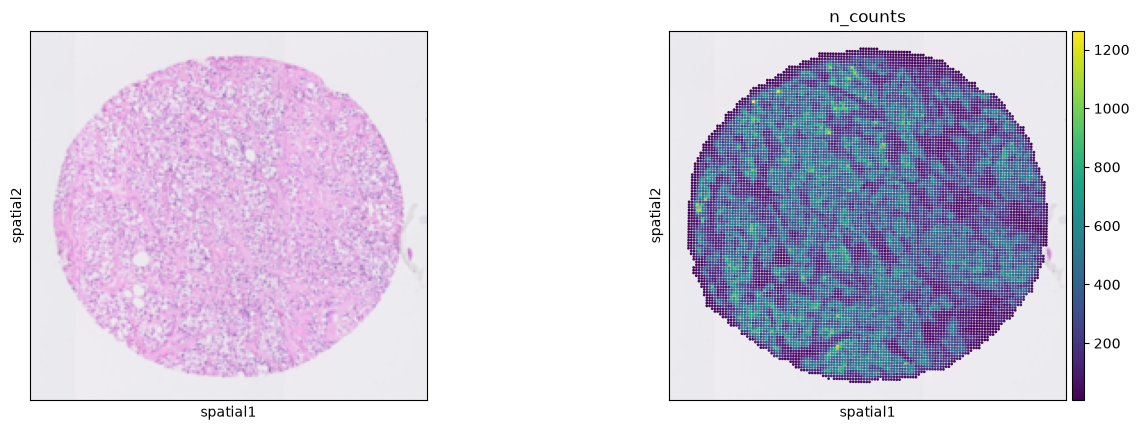

In [16]:
adata.obs["components"] = adata.obs["components"].astype(str)
sc.pl.spatial(adata[adata.obs["components"] == "5"], library_id=library_id, img_key="hires", color=[None, "n_counts"])

/tmp/1538279.tinyfat/ipykernel_1607548/1308442330.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs["components"] == "5"], library_id="breast_cancer_tma", img_key="mask", color=["n_counts", "distance_to_image_mask"])
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


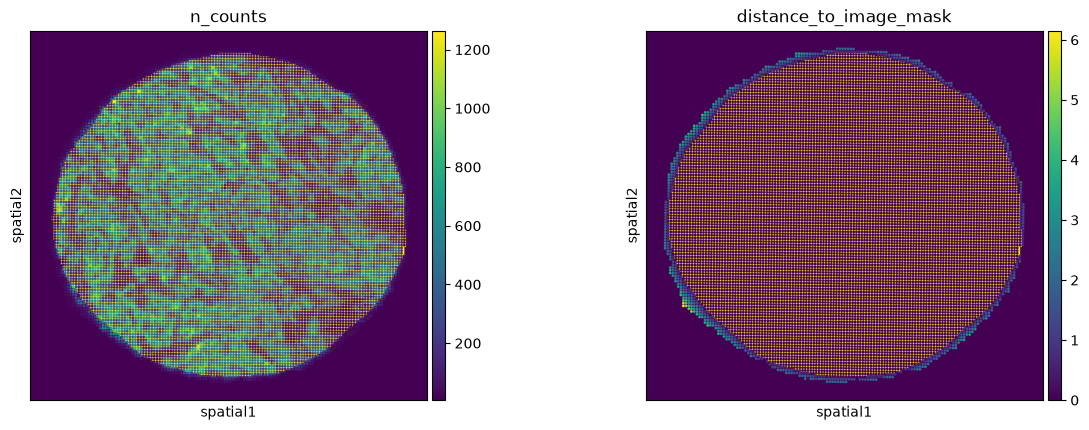

In [17]:
sc.pl.spatial(adata[adata.obs["components"] == "5"], library_id=library_id, img_key="mask", color=["n_counts", "distance_to_image_mask"])

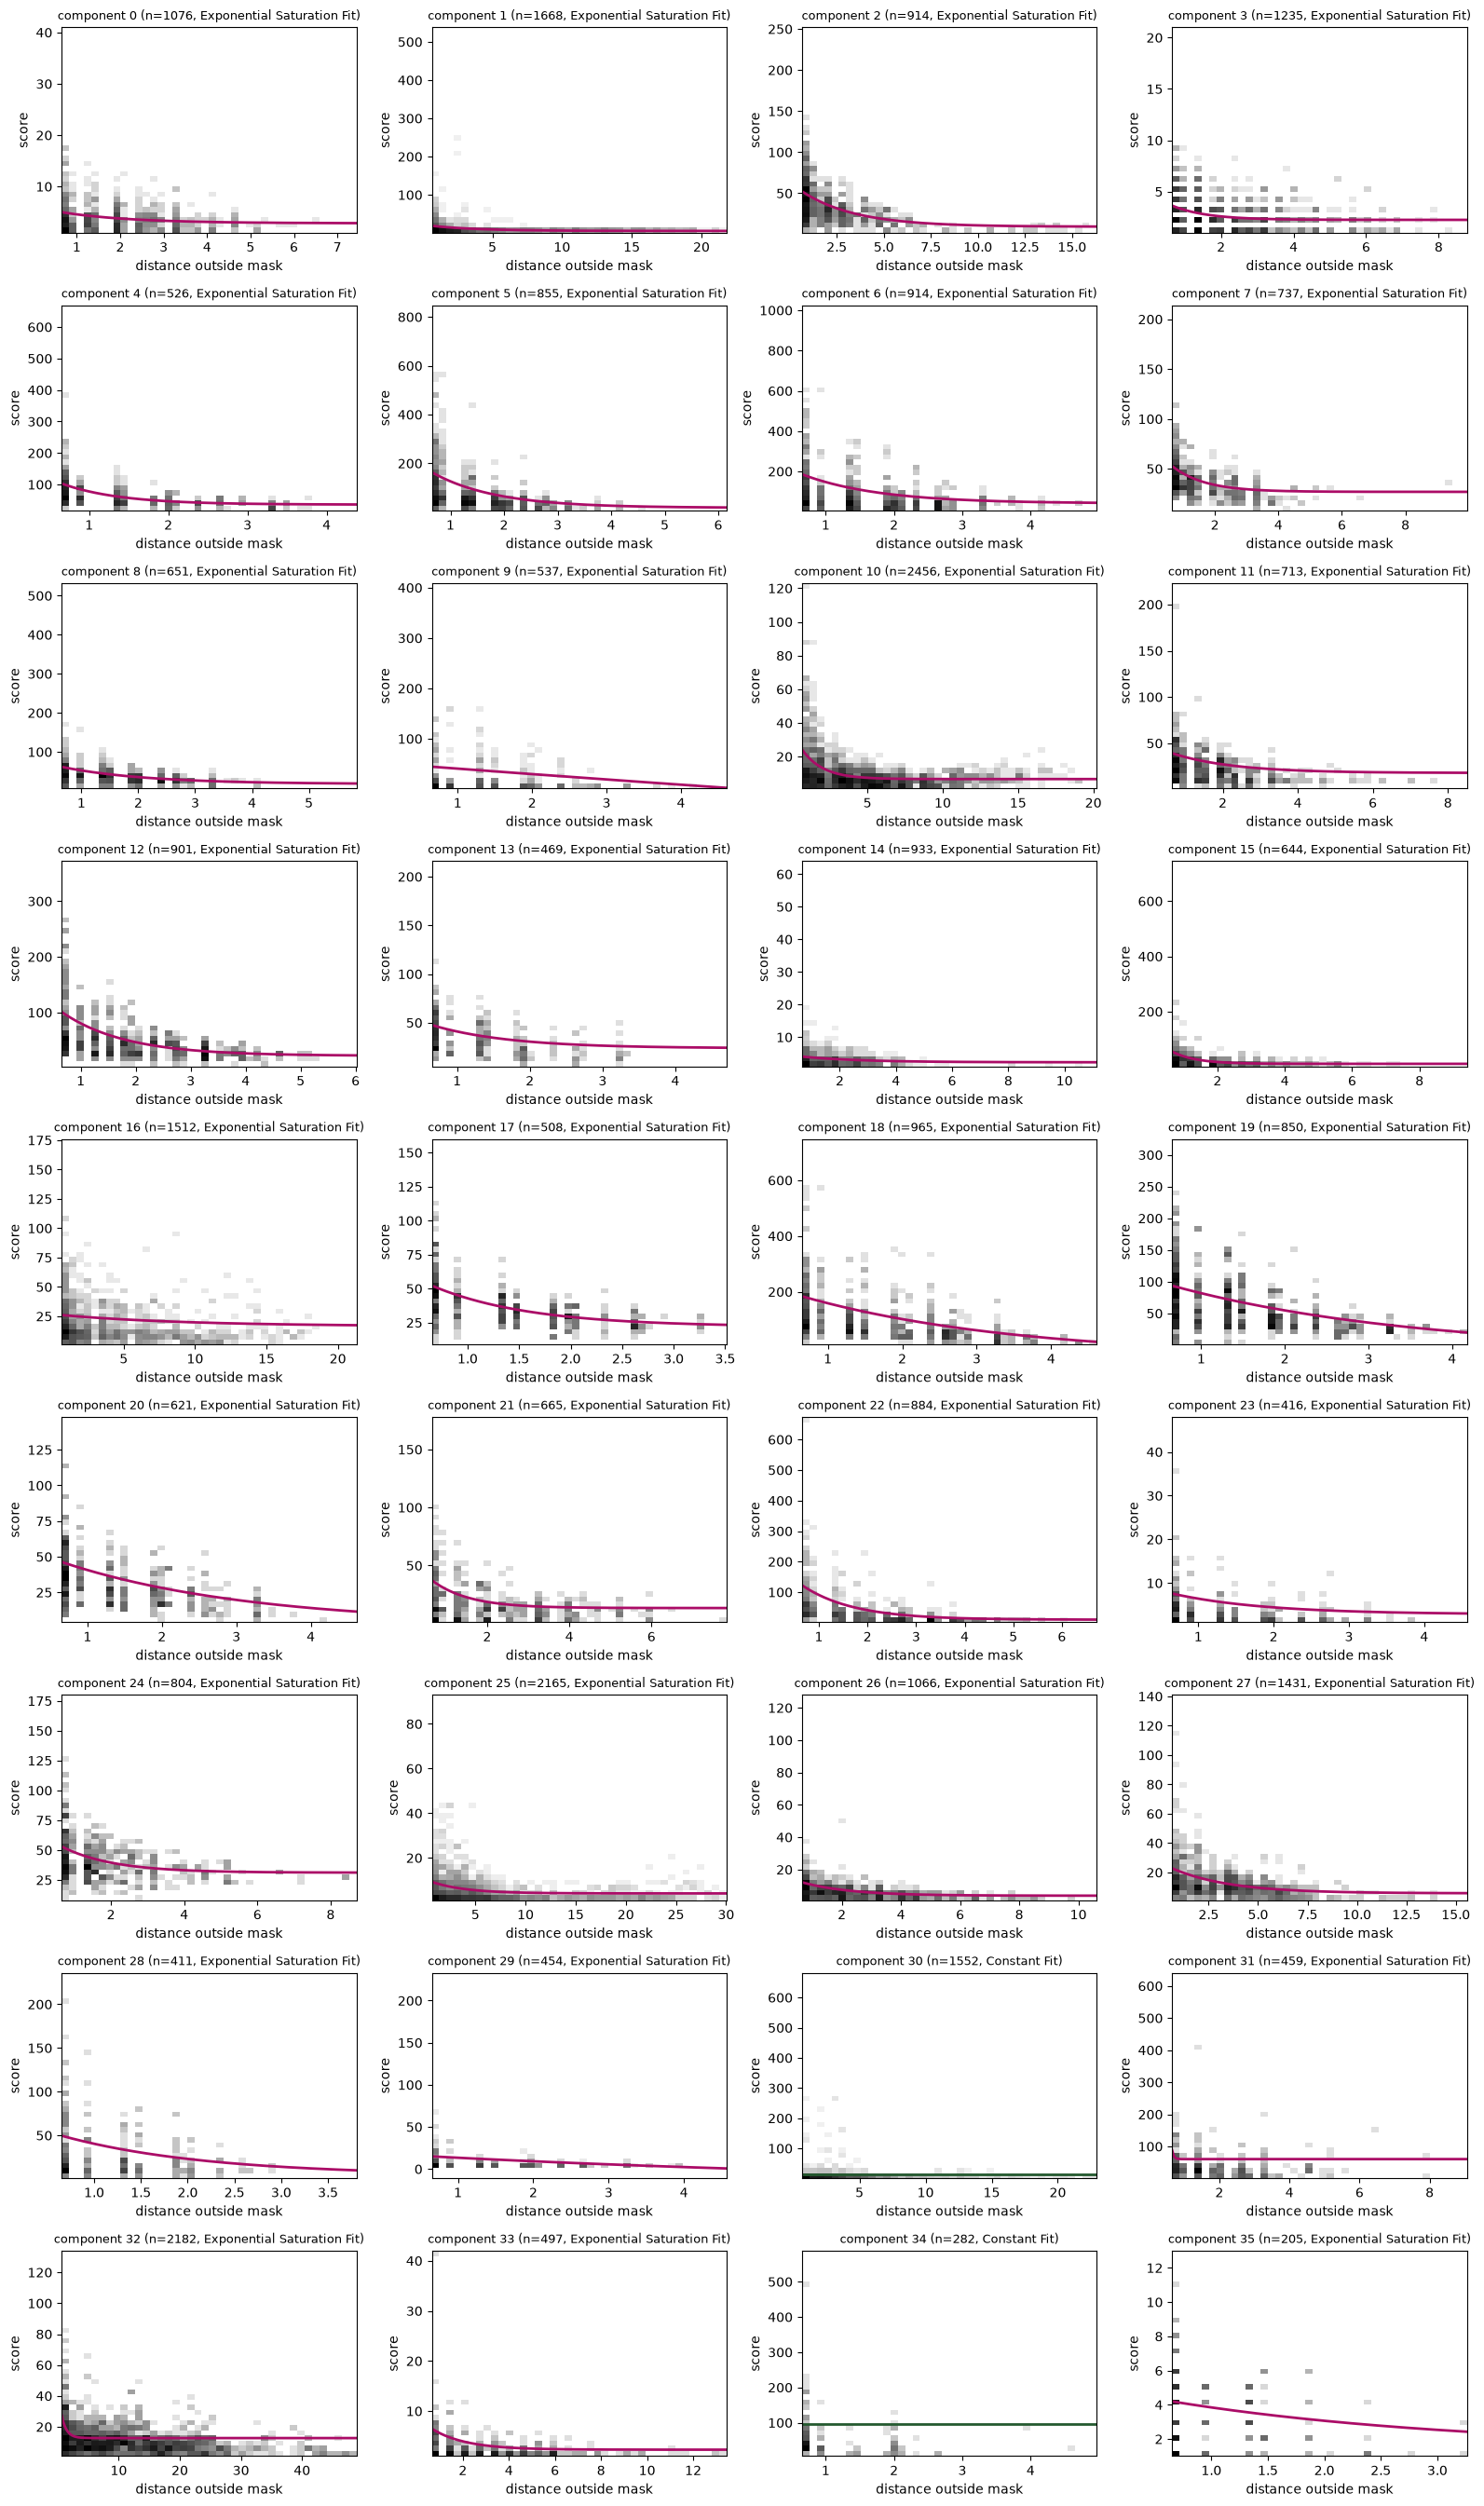

In [18]:
adata.obs["components"] = adata.obs["components"].astype(int)
fig = bosperrus.anndata_api.plot_diffusion(adata, score="n_counts", mask_distance_key="distance_to_image_mask")
plt.show()